# Buy, Borrow, Die

A 65-year-old wealthy taxpayer with appreciated stock wants to fund a major expenditure today. He has three financing paths:

- **Scenario A — Sell upfront.** Sell enough stock at year 0 to net the expenditure after capital gains tax. Hold the residual until death.
- **Scenario B — Borrow & amortize.** Take a securities-backed line of credit (SBLOC) for the full expenditure. Make annual loan payments by selling small chunks of stock for 10 years. After the loan is paid off, hold the residual until death.
- **Scenario C — Borrow, pay interest only, die at age 90.** Pay only interest each year, funded by minimal stock sales. At year 25 he dies; the estate sells stock at *stepped-up* basis to repay the loan (zero capital-gains tax on that sale) and pays estate tax on what remains.

We track the full federal tax incidence — **borrower capital-gains tax + lender ordinary-income tax on interest + federal estate tax** — and what heirs receive after all taxes. We run two scales: \$10M expenditure on a \$30M portfolio (moderate-HNW), and \$100M expenditure on a \$300M portfolio (ultra-HNW).

All model and plotting code lives in [`bbd.py`](bbd.py) next to this notebook; the cells below just import it and drive the scenarios.

**Parameter sources** — federal LTCG 23.8% ([IRS Topic 409](https://www.irs.gov/taxtopics/tc409), [Tax Foundation 2026](https://taxfoundation.org/data/all/federal/2026-tax-brackets/)); federal estate tax 40% above \$15M/\$30M (OBBBA-permanent; [IRS estate tax](https://www.irs.gov/businesses/small-businesses-self-employed/estate-tax), [IRS 2026 inflation](https://www.irs.gov/newsroom/irs-releases-tax-inflation-adjustments-for-tax-year-2026-including-amendments-from-the-one-big-beautiful-bill)); SBLOC rate 5.5% ([Stockstead 2026](https://www.stockstead.com/blog/sbloc-rates-2026-schwab-fidelity-ibkr-morgan-stanley)); lender ordinary-income tax 30% (blended bank/individual); stock growth 7%/yr; horizon 25 years (age 65 → 90).

In [1]:
%load_ext autoreload
%autoreload 2

import bbd
from bbd import Scenario

moderate = Scenario(
    expenditure    = 10_000_000,
    starting_stock = 30_000_000,
    starting_basis = 15_000_000,
)

large = Scenario(
    expenditure    = 100_000_000,
    starting_stock = 300_000_000,
    starting_basis =  75_000_000,
)

## Moderate-HNW scenario ($10M expenditure, $30M starting portfolio, 50% basis)

In [2]:
moderate_r = bbd.run_all(moderate)
print(bbd.comparison_table(moderate_r).to_string(index=False))

                 Scenario    Borrower CGT Lender income tax      Estate tax Total fed revenue   Interest paid    Net to heirs
     A. Sell upfront, die $     1,350,738   $             0 $    28,487,046   $    29,837,784 $             0 $    72,730,569
B. Borrow & amortize, die $     2,428,492   $       980,033 $    29,285,303   $    32,693,828 $     3,266,777 $    73,927,955
C. Borrow, die at horizon $     3,087,485   $     4,125,000 $    32,348,181   $    39,560,666 $    13,750,000 $    78,522,271


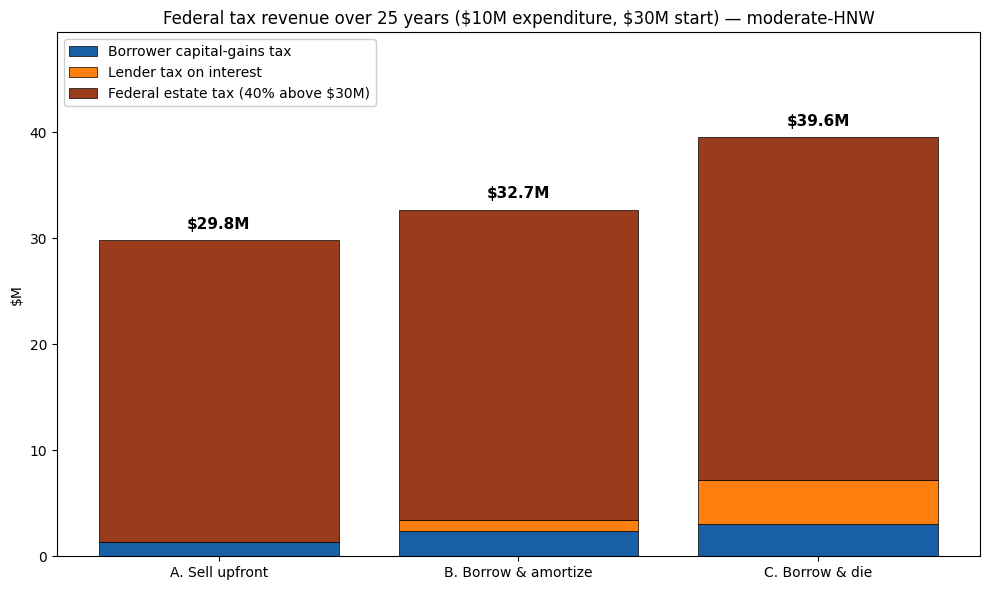

In [3]:
bbd.plot_revenue_stack(moderate_r, moderate, title_suffix='moderate-HNW');

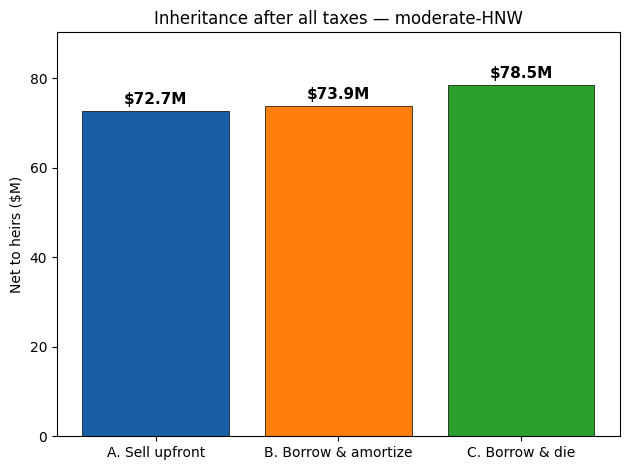

In [4]:
bbd.plot_heirs(moderate_r, moderate, title_suffix='moderate-HNW');

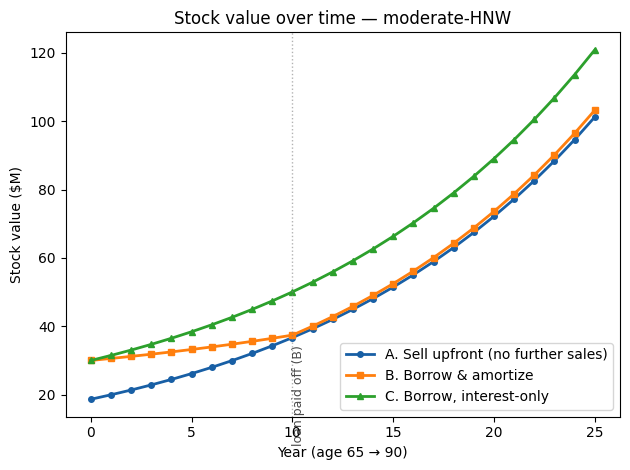

In [5]:
bbd.plot_trajectories(moderate_r, moderate, title_suffix='moderate-HNW');

## Ultra-HNW scenario ($100M expenditure, $300M starting portfolio, 25% basis)

In [6]:
large_r = bbd.run_all(large)
print(bbd.comparison_table(large_r).to_string(index=False))

                 Scenario    Borrower CGT Lender income tax      Estate tax Total fed revenue   Interest paid    Net to heirs
     A. Sell upfront, die $    21,728,545   $             0 $   375,022,525   $   396,751,070 $             0 $   592,533,787
B. Borrow & amortize, die $    32,401,621   $     9,800,331 $   388,083,195   $   430,285,146 $    32,667,769 $   612,124,792
C. Borrow, die at horizon $    36,657,296   $    41,250,000 $   424,441,361   $   502,348,657 $   137,500,000 $   666,662,041


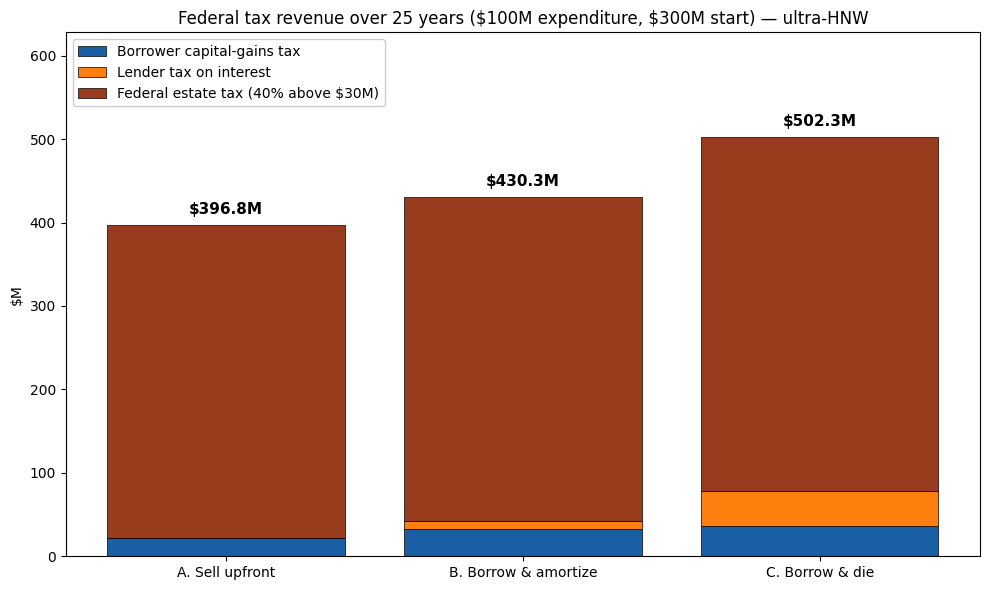

In [7]:
bbd.plot_revenue_stack(large_r, large, title_suffix='ultra-HNW');

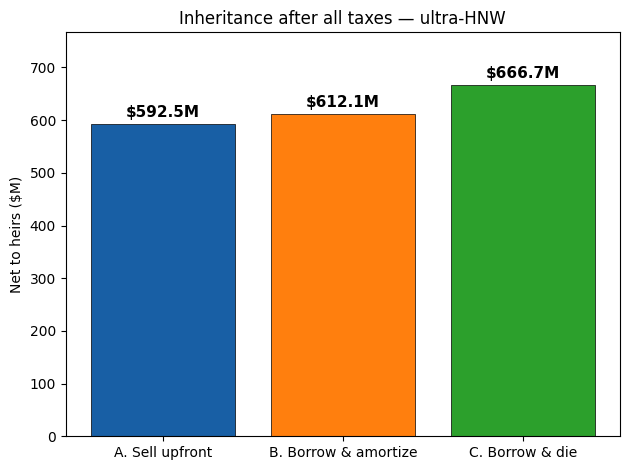

In [8]:
bbd.plot_heirs(large_r, large, title_suffix='ultra-HNW');

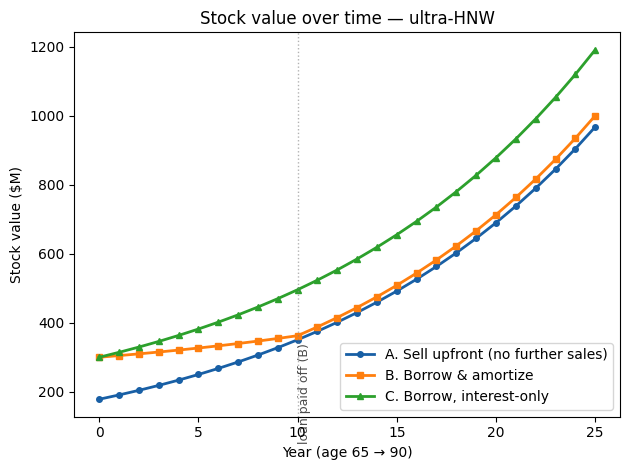

In [9]:
bbd.plot_trajectories(large_r, large, title_suffix='ultra-HNW');

## Side-by-side: federal revenue per dollar of consumption financed

The bigger the estate at year 25, the more of the federal tax bill comes from the **estate tax** (40% above $30M MFJ exemption), not from capital-gains tax. Expressing total federal revenue as a percentage of the expenditure shows how heavily the IRS taxes the *whole* preserved capital base, not just the dollars actually consumed.

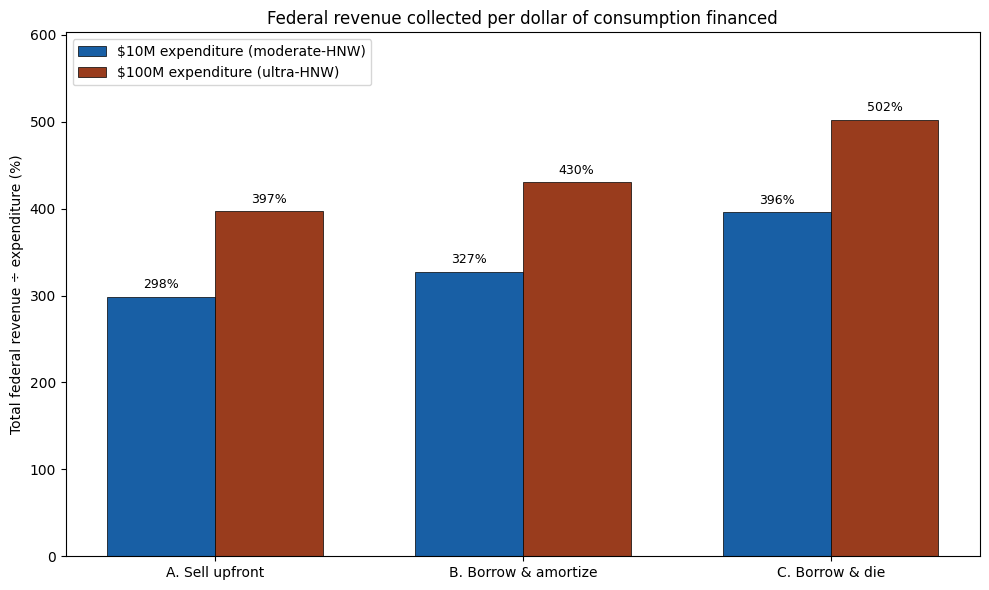

In [10]:
bbd.plot_side_by_side(
    moderate_r, '$10M expenditure (moderate-HNW)', moderate,
    large_r,    '$100M expenditure (ultra-HNW)',  large,
);

## Takeaways

1. **Over a 25-year horizon, even a moderate-HNW estate ($30M start) ends up well above the federal exemption.** By age 90 the position has compounded to $100M+ in every scenario; the 40% estate tax becomes the dominant federal tax for *everyone* in this analysis, in *every* path.
2. **Scenario C is not a tax-free path.** Step-up wipes out capital-gains tax on the post-death sale used to repay the loan — but the larger residual estate produces a bigger estate-tax bill that exceeds the avoided capital-gains tax. **C generates the most federal revenue**, not the least.
3. **Heirs still come out ahead under C** — by ~8% in the moderate case, ~12% in the large case. The advantage is capital preservation, not tax avoidance: the borrower sold less stock during life, so the compounded base at death is bigger, and that more-than-offsets the higher tax bite.
4. **All three financing paths produce roughly similar family wealth at death** — within ~10% of each other. The popular "buy borrow die zeroes out tax" narrative confuses *capital-gains tax* (which step-up eliminates) with *total federal tax* (which the estate tax dominates). The real federal-revenue impact of dying with a big appreciated portfolio is the estate tax, full stop.
5. **At these scales, total federal tax revenue runs 3–5× the original expenditure.** A \$10M consumption today triggers ~\$30–40M of federal taxes over 25 years, almost all of it estate tax. A \$100M consumption today triggers ~\$400–500M. The estate tax does most of the work the unrealized-gains-tax proposals were ostensibly designed to do.
6. **The targeted policy levers are clear.** Eliminating step-up at death closes the genuine loophole (the only mechanism by which capital-gains income permanently escapes federal taxation). Tightening the estate-tax exemption — or its standard valuation games (GRATs, IDGTs, dynasty trusts) — addresses dynastic concentration directly. Annual mark-to-market on unrealized gains does neither, and brings severe mechanical breakage with it (see the [farmer](../farmer/), [entrepreneur](../entrepreneur/), and [public-company](../public-company/) cases).

## Sources

- [IRS Topic 409 — Capital gains and losses](https://www.irs.gov/taxtopics/tc409)
- [Tax Foundation — 2026 Tax Brackets](https://taxfoundation.org/data/all/federal/2026-tax-brackets/)
- [Kiplinger — 2026 capital gains thresholds](https://www.kiplinger.com/taxes/irs-updates-capital-gains-tax-thresholds)
- [IRS — Estate Tax](https://www.irs.gov/businesses/small-businesses-self-employed/estate-tax)
- [IRS — 2026 inflation adjustments (includes OBBBA $15M estate exemption)](https://www.irs.gov/newsroom/irs-releases-tax-inflation-adjustments-for-tax-year-2026-including-amendments-from-the-one-big-beautiful-bill)
- [Pierce Atwood — OBBBA and estate planning](https://www.pierceatwood.com/alerts/one-big-beautiful-bill-act-and-estate-planning-what-you-need-know)
- [Stockstead — SBLOC rate comparison 2026](https://www.stockstead.com/blog/sbloc-rates-2026-schwab-fidelity-ibkr-morgan-stanley)
- [Goldman Sachs — Securities-Based Lines of Credit primer](https://welcome.gsselect.com/content/gsSelect/us/en/insights/Securities-based-lines-of-credit_what-when-why.html)
- [Fidelity — SBLOC overview](https://www.fidelity.com/lending/securities-backed-line-of-credit)